<a href="https://colab.research.google.com/github/MertDikdas/minst-classification/blob/main/MINST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import random
import matplotlib.pyplot as plt

In [66]:
train_data = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

In [67]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [68]:
image.shape

torch.Size([1, 28, 28])

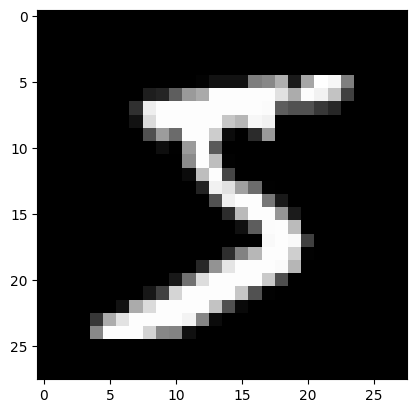

In [69]:
plt.imshow(image.squeeze(), cmap="gray")
plt.show()

In [70]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [71]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

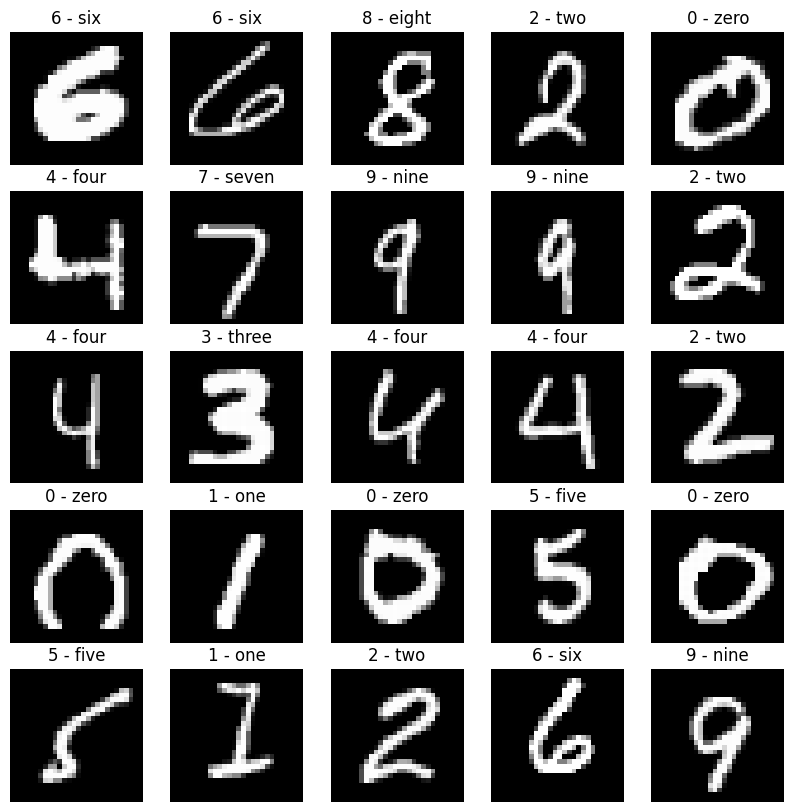

In [72]:
torch.manual_seed(42)
fig = plt.figure(figsize=(10, 10))
rows, cols = 5, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)
plt.show()

In [74]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train dataloader samples : {len(train_dataloader.dataset)}")
print(f"Test dataloader samples : {len(test_dataloader.dataset)}")

Train dataloader samples : 60000
Test dataloader samples : 10000


In [75]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

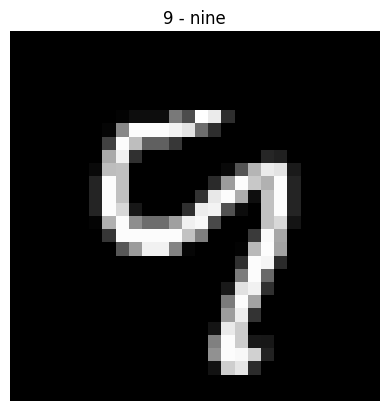

In [76]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size= [1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
plt.show()

In [77]:
class MNISTModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

In [78]:
device = "cuda" if torch.backends.mps.is_available() else "cpu"
device
torch.manual_seed(42)
model = MNISTModel(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model, device

(MNISTModel(
   (block_1): Sequential(
     (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block_2): Sequential(
     (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=490, out_features=10, bias=True)
   )
 ),
 'cpu')

In [79]:
def train_step(model : nn.Module, dataloader : DataLoader, loss_fn : torch.nn.Module , optimizer : torch.optim.Optimizer, device : torch.device):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred_proba = model(X)
    loss = loss_fn(y_pred_proba, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred = torch.argmax(torch.softmax(y_pred_proba, dim=1), dim=1)
    train_acc += (y_pred == y).sum().item()/len(y_pred_proba)
  print(f"Train loss : {train_loss/len(dataloader)}, Train acc : {train_acc/len(dataloader)}")
  return train_loss, train_acc
def test_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, device: torch.device):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      y_pred_proba = model(X)
      loss = loss_fn(y_pred_proba, y)
      test_loss += loss.item()
      y_pred = torch.argmax(torch.softmax(y_pred_proba, dim=1), dim=1)
      test_acc += (y_pred == y).sum().item()/len(y_pred_proba)
  print(f"Test loss : {test_loss/len(dataloader)}, Test acc : {test_acc/len(dataloader)}")
  return test_loss, test_acc

In [80]:
optim = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
epochs = 3
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n----------")
  train_step(model, train_dataloader, loss_fn, optim, device)
  test_step(model, test_dataloader, loss_fn, device)

Epoch: 0
----------
Train loss : 0.2279085437680284, Train acc : 0.927
Test loss : 0.0744361760122285, Test acc : 0.9759384984025559
Epoch: 1
----------
Train loss : 0.07550003051729873, Train acc : 0.9762
Test loss : 0.0531135412966018, Test acc : 0.985323482428115
Epoch: 2
----------
Train loss : 0.05783284757019331, Train acc : 0.9816833333333334
Test loss : 0.05540320361038661, Test acc : 0.9832268370607029


In [81]:
def eval_model(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, device: torch.device):
    model.eval()
    loss, acc = 0, 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            y_pred_logits = model(X)

            loss += loss_fn(y_pred_logits, y).item()

            y_pred = torch.argmax(y_pred_logits, dim=1)

            acc += (y_pred == y).sum().item() / len(y)
        loss /= len(dataloader)
        acc /= len(dataloader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss,
            "model_acc": acc}

In [82]:
torch.manual_seed(42)

model_results = eval_model(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)
print(model_results)

{'model_name': 'MNISTModel', 'model_loss': 0.05540320361038661, 'model_acc': 0.9832268370607029}


In [113]:
def make_predictions(model: nn.Module, data: list, device: torch.device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit, dim=1)
      pred_prob = torch.argmax(pred_prob, dim=1)
      pred_probs.append(pred_prob.item())
  return torch.tensor(pred_probs)

In [118]:
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=10):
  test_samples.append(sample)
  test_labels.append(label)
pred_probs= make_predictions(model=model,
                             data=test_samples, device=device)
pred_probs

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1, 1])

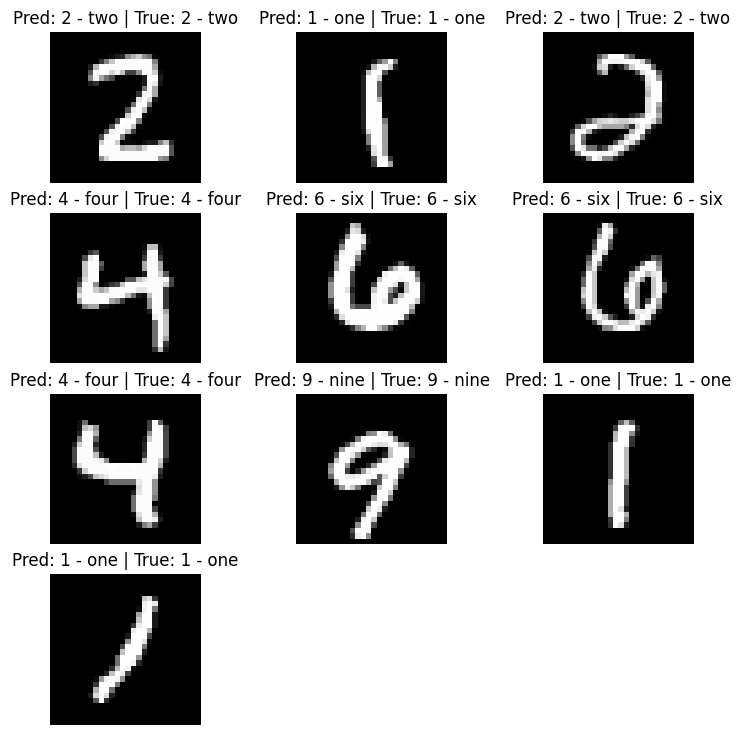

In [119]:
plt.figure(figsize=(9, 9))
rows=4
cols=3
for i, sample in enumerate(test_samples):
  plt.subplot(rows, cols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = class_names[pred_probs[i]]
  true_label = class_names[test_labels[i]]
  plt.title(f"Pred: {pred_label} | True: {true_label}")
  plt.axis(False)
plt.show()